In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [2]:
ROOT = Path.cwd()
PROJECT_ROOT = ROOT / "19042026"

E00_ROOT = PROJECT_ROOT / "E00_hyperparameter_tuning"
E03_ROOT = PROJECT_ROOT / "E03_augmentation_overfitting"
E05_ROOT = PROJECT_ROOT / "E05_architecture_comparison"
EXP_ROOT = PROJECT_ROOT / "E06_threshold_optimization"

SOURCE_RUN = "E03_aug_strong"

SUBDIRS = [
    "metrics",
    "predictions",
    "plots",
    "confusion_matrices",
    "summary"
]

for sub in SUBDIRS:
    (EXP_ROOT / sub).mkdir(parents=True, exist_ok=True)

print("E06 root:", EXP_ROOT)
print("Source model:", SOURCE_RUN)

E06 root: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E06_threshold_optimization
Source model: E03_aug_strong


In [3]:
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4)

def evaluate_binary(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "kappa": float(kappa),
        "roc_auc": float(roc) if not np.isnan(roc) else None,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

def plot_confusion(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    labels = ["Non-Melanoma", "Melanoma"]
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(2))
    ax.set_yticks(range(2))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

In [4]:
model_path = E03_ROOT / "models" / SOURCE_RUN / f"{SOURCE_RUN}.keras"

X_val_path = E03_ROOT / "feature_cache" / SOURCE_RUN / "X_val.npy"
y_val_path = E03_ROOT / "feature_cache" / SOURCE_RUN / "y_val.npy"

X_test_path = E03_ROOT / "feature_cache" / SOURCE_RUN / "X_test.npy"
y_test_path = E03_ROOT / "feature_cache" / SOURCE_RUN / "y_test.npy"

test_split_path = E00_ROOT / "summary" / "test_split.csv"

for p in [model_path, X_val_path, y_val_path, X_test_path, y_test_path, test_split_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

model = keras.models.load_model(model_path)

X_val = np.load(X_val_path)
y_val = np.load(y_val_path)

X_test = np.load(X_test_path)
y_test = np.load(y_test_path)

test_df = pd.read_csv(test_split_path)

print("Model loaded:", model_path)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Model loaded: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E03_augmentation_overfitting\models\E03_aug_strong\E03_aug_strong.keras
Val: (3269, 2048) (3269,)
Test: (3270, 2048) (3270,)


In [5]:
y_val_prob = model.predict(X_val, verbose=0).ravel()
y_test_prob = model.predict(X_test, verbose=0).ravel()

print("Validation probabilities:", y_val_prob[:5])
print("Test probabilities:", y_test_prob[:5])

Validation probabilities: [0.05893989 0.01946161 0.00164503 0.01964898 0.01234378]
Test probabilities: [0.13231914 0.2137306  0.05114429 0.0083958  0.1329609 ]


In [6]:
thresholds = np.arange(0.05, 0.96, 0.01)

val_results = []

for t in thresholds:
    metrics = evaluate_binary(y_val, y_val_prob, threshold=t)
    val_results.append(metrics)

val_results_df = pd.DataFrame(val_results)

# Main rule: maximize F1, then recall, then kappa
val_results_sorted = val_results_df.sort_values(
    by=["f1", "recall", "kappa"],
    ascending=False
).reset_index(drop=True)

best_threshold = float(val_results_sorted.iloc[0]["threshold"])

val_results_df.to_csv(EXP_ROOT / "summary" / "E06_validation_threshold_search.csv", index=False)

print("Best threshold from validation:", best_threshold)
val_results_sorted.head(10)

Best threshold from validation: 0.6100000000000001


,threshold,accuracy,precision,recall,f1,kappa,roc_auc,tn,fp,fn,tp
0,0.61,0.976751,0.285714,0.206897,0.240000,0.228502,0.849171,3181,30,46,12
1,0.58,0.974610,0.254902,0.224138,0.238532,0.225676,0.849171,3173,38,45,13
2,0.60,0.976445,0.279070,0.206897,0.237624,0.225930,0.849171,3180,31,46,12
3,0.66,0.980116,0.370370,0.172414,0.235294,0.226576,0.849171,3194,17,48,10
4,0.64,0.977975,0.305556,0.189655,0.234043,0.223490,0.849171,3186,25,47,11
5,0.59,0.975834,0.266667,0.206897,0.233010,0.220932,0.849171,3178,33,46,12
6,0.63,0.977669,0.297297,0.189655,0.231579,0.220810,0.849171,3185,26,47,11
7,0.57,0.973386,0.236364,0.224138,0.230088,0.216557,0.849171,3169,42,45,13
8,0.62,0.977363,0.289474,0.189655,0.229167,0.218185,0.849171,3184,27,47,11
9,0.52,0.968798,0.202703,0.258621,0.227273,0.211589,0.849171,3152,59,43,15


In [7]:
test_default = evaluate_binary(y_test, y_test_prob, threshold=0.50)
test_optimized = evaluate_binary(y_test, y_test_prob, threshold=best_threshold)

comparison_df = pd.DataFrame([
    {"setting": "default_threshold_0.50", **test_default},
    {"setting": "optimized_threshold", **test_optimized}
])

comparison_df.to_csv(EXP_ROOT / "summary" / "E06_test_threshold_comparison.csv", index=False)

save_json(test_default, EXP_ROOT / "metrics" / "test_default_threshold_metrics.json")
save_json(test_optimized, EXP_ROOT / "metrics" / "test_optimized_threshold_metrics.json")

comparison_df

,setting,threshold,accuracy,precision,recall,f1,kappa,roc_auc,tn,fp,fn,tp
0,default_threshold_0.50,0.50,0.963914,0.142857,0.206897,0.169014,0.151202,0.836446,3140,72,46,12
1,optimized_threshold,0.61,0.974312,0.157895,0.103448,0.125000,0.112538,0.836446,3180,32,52,6


In [8]:
pred_df = pd.DataFrame({
    "image_name": test_df["image_name"].values,
    "true_label": y_test,
    "pred_prob": y_test_prob,
    "pred_label_default_0_50": (y_test_prob >= 0.50).astype(int),
    "pred_label_optimized": (y_test_prob >= best_threshold).astype(int)
})

pred_df.to_csv(EXP_ROOT / "predictions" / "E06_test_predictions_threshold_optimized.csv", index=False)

pred_df.head()

,image_name,true_label,pred_prob,pred_label_default_0_50,pred_label_optimized
0,ISIC_2790561,0,0.132319,0,0
1,ISIC_0696556,0,0.213731,0,0
2,ISIC_9462346,0,0.051144,0,0
3,ISIC_8739046,0,0.008396,0,0
4,ISIC_8926705,0,0.132961,0,0


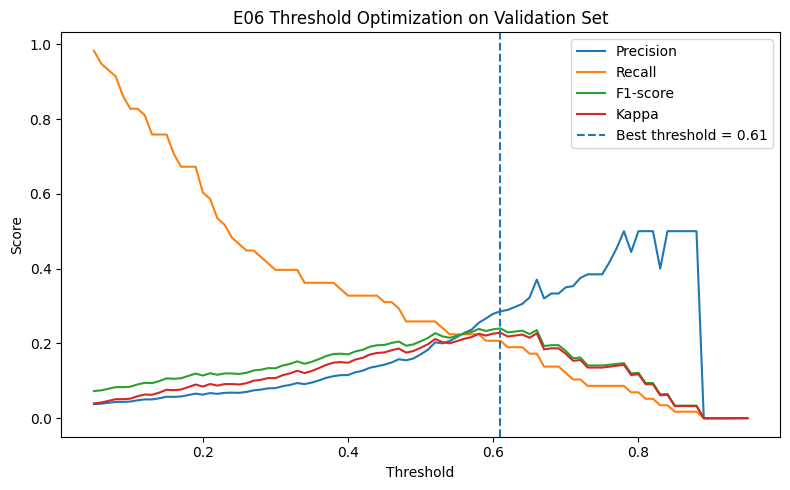

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(val_results_df["threshold"], val_results_df["precision"], label="Precision")
plt.plot(val_results_df["threshold"], val_results_df["recall"], label="Recall")
plt.plot(val_results_df["threshold"], val_results_df["f1"], label="F1-score")
plt.plot(val_results_df["threshold"], val_results_df["kappa"], label="Kappa")
plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("E06 Threshold Optimization on Validation Set")
plt.legend()
plt.tight_layout()
plt.savefig(EXP_ROOT / "plots" / "E06_threshold_optimization_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
cm_default = confusion_matrix(y_test, (y_test_prob >= 0.50).astype(int), labels=[0, 1])
cm_optimized = confusion_matrix(y_test, (y_test_prob >= best_threshold).astype(int), labels=[0, 1])

plot_confusion(
    cm_default,
    "Confusion Matrix - Default Threshold 0.50",
    EXP_ROOT / "confusion_matrices" / "E06_cm_default_threshold.png"
)

plot_confusion(
    cm_optimized,
    f"Confusion Matrix - Optimized Threshold {best_threshold:.2f}",
    EXP_ROOT / "confusion_matrices" / "E06_cm_optimized_threshold.png"
)

print("Default CM:")
print(cm_default)

print("\nOptimized CM:")
print(cm_optimized)

Default CM:
[[3140   72]
 [  46   12]]

Optimized CM:
[[3180   32]
 [  52    6]]


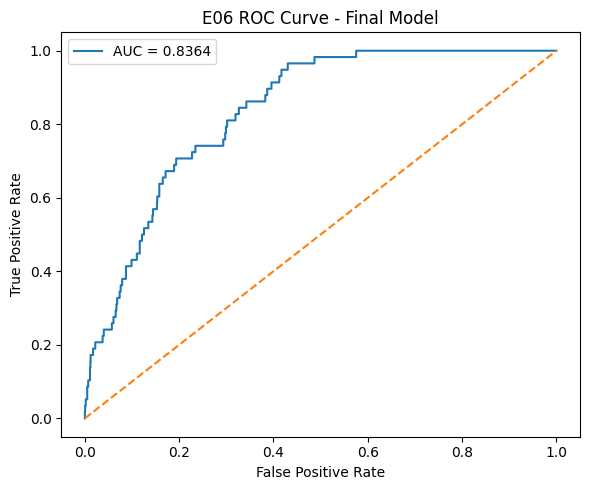

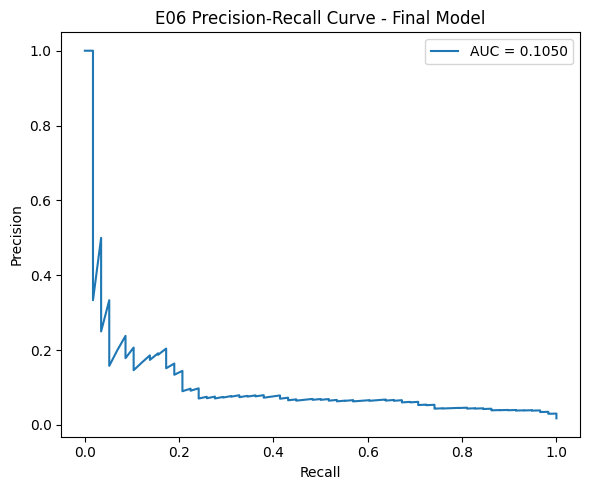

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("E06 ROC Curve - Final Model")
plt.legend()
plt.tight_layout()
plt.savefig(EXP_ROOT / "plots" / "E06_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("E06 Precision-Recall Curve - Final Model")
plt.legend()
plt.tight_layout()
plt.savefig(EXP_ROOT / "plots" / "E06_pr_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
manifest = {
    "experiment_id": "E06",
    "experiment_name": "Threshold Optimization",
    "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "source_model": SOURCE_RUN,
    "source_root": str(E03_ROOT),
    "experiment_root": str(EXP_ROOT),
    "threshold_selection_rule": "Best validation F1, then recall, then kappa",
    "default_threshold": 0.50,
    "optimized_threshold": best_threshold,
    "test_default_metrics": test_default,
    "test_optimized_metrics": test_optimized
}

save_json(manifest, EXP_ROOT / "summary" / "experiment_manifest.json")

print("E06 finished.")
print(json.dumps(manifest, indent=4))

E06 finished.
{
    "experiment_id": "E06",
    "experiment_name": "Threshold Optimization",
    "date_created": "2026-04-24 13:38:52",
    "source_model": "E03_aug_strong",
    "source_root": "C:\\Users\\User\\Desktop\\Melanoma Detection Based on Deep Neural Networks Draft 01042026\\19042026\\E03_augmentation_overfitting",
    "experiment_root": "C:\\Users\\User\\Desktop\\Melanoma Detection Based on Deep Neural Networks Draft 01042026\\19042026\\E06_threshold_optimization",
    "threshold_selection_rule": "Best validation F1, then recall, then kappa",
    "default_threshold": 0.5,
    "optimized_threshold": 0.6100000000000001,
    "test_default_metrics": {
        "threshold": 0.5,
        "accuracy": 0.963914373088685,
        "precision": 0.14285714285714285,
        "recall": 0.20689655172413793,
        "f1": 0.16901408450704225,
        "kappa": 0.151202386294644,
        "roc_auc": 0.8364457637308369,
        "tn": 3140,
        "fp": 72,
        "fn": 46,
        "tp": 12
    }

In [13]:
# ==========================================
# DETAILED THRESHOLD ANALYSIS - VALIDATION + TEST
# ==========================================

thresholds = np.arange(0.01, 0.991, 0.01)

all_threshold_rows = []

for t in thresholds:
    val_m = evaluate_binary(y_val, y_val_prob, threshold=t)
    test_m = evaluate_binary(y_test, y_test_prob, threshold=t)

    row = {
        "threshold": round(float(t), 2),

        "val_accuracy": val_m["accuracy"],
        "val_precision": val_m["precision"],
        "val_recall": val_m["recall"],
        "val_f1": val_m["f1"],
        "val_kappa": val_m["kappa"],
        "val_tn": val_m["tn"],
        "val_fp": val_m["fp"],
        "val_fn": val_m["fn"],
        "val_tp": val_m["tp"],

        "test_accuracy": test_m["accuracy"],
        "test_precision": test_m["precision"],
        "test_recall": test_m["recall"],
        "test_f1": test_m["f1"],
        "test_kappa": test_m["kappa"],
        "test_tn": test_m["tn"],
        "test_fp": test_m["fp"],
        "test_fn": test_m["fn"],
        "test_tp": test_m["tp"],
    }

    all_threshold_rows.append(row)

threshold_full_df = pd.DataFrame(all_threshold_rows)

threshold_full_df.to_csv(
    EXP_ROOT / "summary" / "E06_all_thresholds_validation_and_test.csv",
    index=False
)

print("Top thresholds by VALIDATION F1:")
display(threshold_full_df.sort_values(
    by=["val_f1", "val_recall", "val_kappa"],
    ascending=False
).head(15))

print("Top thresholds by TEST F1 - exploratory only:")
display(threshold_full_df.sort_values(
    by=["test_f1", "test_recall", "test_kappa"],
    ascending=False
).head(15))

print("Top thresholds by TEST RECALL - exploratory only:")
display(threshold_full_df.sort_values(
    by=["test_recall", "test_f1", "test_precision"],
    ascending=False
).head(15))

Top thresholds by VALIDATION F1:


,threshold,val_accuracy,val_precision,val_recall,val_f1,val_kappa,val_tn,val_fp,val_fn,val_tp,test_accuracy,test_precision,test_recall,test_f1,test_kappa,test_tn,test_fp,test_fn,test_tp
60,0.61,0.976751,0.285714,0.206897,0.240000,0.228502,3181,30,46,12,0.974312,0.157895,0.103448,0.125000,0.112538,3180,32,52,6
57,0.58,0.974610,0.254902,0.224138,0.238532,0.225676,3173,38,45,13,0.973394,0.177778,0.137931,0.155340,0.142043,3175,37,50,8
59,0.60,0.976445,0.279070,0.206897,0.237624,0.225930,3180,31,46,12,0.973700,0.150000,0.103448,0.122449,0.109556,3178,34,52,6
65,0.66,0.980116,0.370370,0.172414,0.235294,0.226576,3194,17,48,10,0.977370,0.192308,0.086207,0.119048,0.109267,3191,21,53,5
63,0.64,0.977975,0.305556,0.189655,0.234043,0.223490,3186,25,47,11,0.976758,0.178571,0.086207,0.116279,0.105953,3189,23,53,5
58,0.59,0.975834,0.266667,0.206897,0.233010,0.220932,3178,33,46,12,0.974006,0.186047,0.137931,0.158416,0.145511,3177,35,50,8
62,0.63,0.977669,0.297297,0.189655,0.231579,0.220810,3185,26,47,11,0.976147,0.187500,0.103448,0.133333,0.122262,3186,26,52,6
56,0.57,0.973386,0.236364,0.224138,0.230088,0.216557,3169,42,45,13,0.973089,0.200000,0.172414,0.185185,0.171580,3172,40,48,10
61,0.62,0.977363,0.289474,0.189655,0.229167,0.218185,3184,27,47,11,0.976147,0.187500,0.103448,0.133333,0.122262,3186,26,52,6
51,0.52,0.968798,0.202703,0.258621,0.227273,0.211589,3152,59,43,15,0.967584,0.157143,0.189655,0.171875,0.155492,3153,59,47,11


Top thresholds by TEST F1 - exploratory only:


,threshold,val_accuracy,val_precision,val_recall,val_f1,val_kappa,val_tn,val_fp,val_fn,val_tp,test_accuracy,test_precision,test_recall,test_f1,test_kappa,test_tn,test_fp,test_fn,test_tp
56,0.57,0.973386,0.236364,0.224138,0.230088,0.216557,3169,42,45,13,0.973089,0.200000,0.172414,0.185185,0.171580,3172,40,48,10
55,0.56,0.972775,0.228070,0.224138,0.226087,0.212232,3167,44,45,13,0.972783,0.196078,0.172414,0.183486,0.169705,3171,41,48,10
54,0.55,0.971857,0.216667,0.224138,0.220339,0.206013,3164,47,45,13,0.970948,0.175439,0.172414,0.173913,0.159128,3165,47,48,10
51,0.52,0.968798,0.202703,0.258621,0.227273,0.211589,3152,59,43,15,0.967584,0.157143,0.189655,0.171875,0.155492,3153,59,47,11
49,0.50,0.964515,0.170455,0.258621,0.205479,0.188115,3138,73,43,15,0.963914,0.142857,0.206897,0.169014,0.151202,3140,72,46,12
53,0.54,0.970939,0.206349,0.224138,0.214876,0.200097,3161,50,45,13,0.969419,0.161290,0.172414,0.166667,0.151108,3160,52,48,10
48,0.49,0.962680,0.159574,0.258621,0.197368,0.179360,3132,79,43,15,0.962997,0.137931,0.206897,0.165517,0.147370,3137,75,46,12
50,0.51,0.966351,0.182927,0.258621,0.214286,0.197609,3144,67,43,15,0.966055,0.146667,0.189655,0.165414,0.148378,3148,64,47,11
52,0.53,0.969410,0.200000,0.241379,0.218750,0.203289,3155,56,44,14,0.968196,0.151515,0.172414,0.161290,0.145150,3156,56,48,10
58,0.59,0.975834,0.266667,0.206897,0.233010,0.220932,3178,33,46,12,0.974006,0.186047,0.137931,0.158416,0.145511,3177,35,50,8


Top thresholds by TEST RECALL - exploratory only:


,threshold,val_accuracy,val_precision,val_recall,val_f1,val_kappa,val_tn,val_fp,val_fn,val_tp,test_accuracy,test_precision,test_recall,test_f1,test_kappa,test_tn,test_fp,test_fn,test_tp
1,0.02,0.403793,0.028899,1.000000,0.056174,0.022461,1262,1949,0,58,0.390214,0.028265,1.000000,0.054976,0.021209,1218,1994,0,58
0,0.01,0.293974,0.024514,1.000000,0.047855,0.013693,903,2308,0,58,0.283486,0.024157,1.000000,0.047174,0.012986,869,2343,0,58
3,0.04,0.516060,0.034799,0.982759,0.067217,0.034115,1630,1581,1,57,0.498777,0.033628,0.982759,0.065031,0.031823,1574,1638,1,57
2,0.03,0.465280,0.032115,1.000000,0.062232,0.028843,1463,1748,0,58,0.450459,0.030761,0.982759,0.059655,0.026157,1416,1796,1,57
4,0.05,0.552157,0.037500,0.982759,0.072243,0.039410,1748,1463,1,57,0.541590,0.036059,0.965517,0.069522,0.036576,1715,1497,2,56
5,0.06,0.580606,0.038651,0.948276,0.074274,0.041597,1843,1368,3,55,0.580122,0.038596,0.948276,0.074174,0.041502,1842,1370,3,55
6,0.07,0.612420,0.041002,0.931034,0.078545,0.046125,1948,1263,4,54,0.609786,0.039334,0.896552,0.075362,0.042835,1942,1270,6,52
7,0.08,0.641175,0.043407,0.913793,0.082877,0.050720,2043,1168,5,53,0.640367,0.041051,0.862069,0.078370,0.046068,2044,1168,8,50
8,0.09,0.660753,0.043440,0.862069,0.082713,0.050641,2110,1101,8,50,0.670336,0.043828,0.844828,0.083333,0.051340,2143,1069,9,49
9,0.10,0.679719,0.044240,0.827586,0.083990,0.052059,2174,1037,10,48,0.694495,0.045411,0.810345,0.086002,0.054232,2224,988,11,47


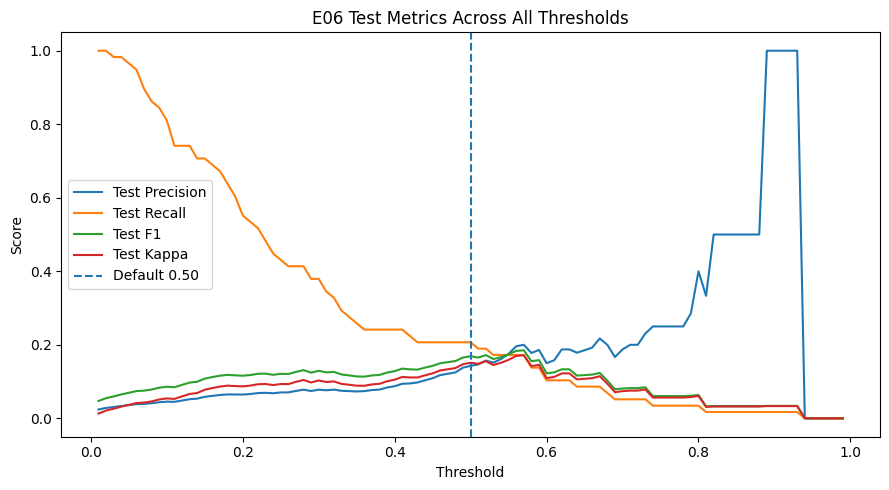

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_full_df["threshold"], threshold_full_df["test_precision"], label="Test Precision")
plt.plot(threshold_full_df["threshold"], threshold_full_df["test_recall"], label="Test Recall")
plt.plot(threshold_full_df["threshold"], threshold_full_df["test_f1"], label="Test F1")
plt.plot(threshold_full_df["threshold"], threshold_full_df["test_kappa"], label="Test Kappa")
plt.axvline(0.50, linestyle="--", label="Default 0.50")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("E06 Test Metrics Across All Thresholds")
plt.legend()
plt.tight_layout()
plt.savefig(EXP_ROOT / "plots" / "E06_test_all_thresholds_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
for t in [0.50,0.55,0.60,0.61]:
    print("Threshold:", t)
    print(evaluate_binary(y_test, y_test_prob, t))
    print("-"*50)

Threshold: 0.5
{'threshold': 0.5, 'accuracy': 0.963914373088685, 'precision': 0.14285714285714285, 'recall': 0.20689655172413793, 'f1': 0.16901408450704225, 'kappa': 0.151202386294644, 'roc_auc': 0.8364457637308369, 'tn': 3140, 'fp': 72, 'fn': 46, 'tp': 12}
--------------------------------------------------
Threshold: 0.55
{'threshold': 0.55, 'accuracy': 0.9709480122324159, 'precision': 0.17543859649122806, 'recall': 0.1724137931034483, 'f1': 0.17391304347826086, 'kappa': 0.15912818930375328, 'roc_auc': 0.8364457637308369, 'tn': 3165, 'fp': 47, 'fn': 48, 'tp': 10}
--------------------------------------------------
Threshold: 0.6
{'threshold': 0.6, 'accuracy': 0.9737003058103976, 'precision': 0.15, 'recall': 0.10344827586206896, 'f1': 0.12244897959183673, 'kappa': 0.10955607624596286, 'roc_auc': 0.8364457637308369, 'tn': 3178, 'fp': 34, 'fn': 52, 'tp': 6}
--------------------------------------------------
Threshold: 0.61
{'threshold': 0.61, 'accuracy': 0.9743119266055046, 'precision': 0